In [53]:
!pip install pandas numpy scikit-learn matplotlib seaborn joblib flask

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error, precision_score
import joblib

In [55]:
import kagglehub
path = kagglehub.dataset_download("microize/newyork-yellow-taxi-trip-data-2020-2019")

Using Colab cache for faster access to the 'newyork-yellow-taxi-trip-data-2020-2019' dataset.


In [56]:
import os

print(path)
print(os.listdir(path))

/kaggle/input/newyork-yellow-taxi-trip-data-2020-2019
['yellow_tripdata_2019-10.csv', 'yellow_tripdata_2019-02.csv', 'yellow_tripdata_2019-03.csv', 'yellow_tripdata_2020-04.csv', 'taxi+_zone_lookup.csv', 'yellow_tripdata_2019-09.csv', 'yellow_tripdata_2019-12.csv', 'yellow_tripdata_2020-03.csv', 'yellow_tripdata_2019-07.csv', 'yellow_tripdata_2019-11.csv', 'yellow_tripdata_2019-05.csv', 'taxi_zones', 'yellow_tripdata_2020-01.csv', 'yellow_tripdata_2020-06.csv', 'yellow_tripdata_2020-02.csv', 'yellow_tripdata_2020-05.csv', 'yellow_tripdata_2019-04.csv', 'yellow_tripdata_2019-01.csv', 'yellow_tripdata_2019-08.csv', 'yellow_tripdata_2019-06.csv']


In [57]:
import pandas as pd

csv_path = path + "/yellow_tripdata_2019-04.csv"

In [58]:
df = pd.read_csv(csv_path, parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])
df = df.sample(200000, random_state=42)

In [59]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
6272258,2,2019-04-26 08:09:14,2019-04-26 08:29:56,1,6.47,1,N,162,261,2,22.0,0.0,0.5,0.00,0.0,0.3,25.30,2.5
6885367,2,2019-04-28 17:25:15,2019-04-28 17:30:58,5,1.22,1,N,229,161,2,6.0,0.0,0.5,0.00,0.0,0.3,9.30,2.5
6995579,2,2019-04-29 09:32:23,2019-04-29 09:35:27,2,0.93,1,N,158,246,1,5.0,0.0,0.5,1.66,0.0,0.3,9.96,2.5
3462481,2,2019-04-14 11:06:02,2019-04-14 11:26:36,1,2.97,1,N,48,79,1,14.5,0.0,0.5,2.00,0.0,0.3,19.80,2.5
1385849,2,2019-04-06 10:24:57,2019-04-06 10:40:49,1,5.40,1,N,13,107,1,18.0,0.0,0.5,4.26,0.0,0.3,25.56,2.5


In [60]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


In [61]:
df_clean = df.copy()

In [62]:
df_clean['pickup_datetime'] = pd.to_datetime(df_clean['tpep_pickup_datetime'])
df_clean['hour_of_day'] = df_clean['pickup_datetime'].dt.hour
df_clean['day_of_week'] = df_clean['pickup_datetime'].dt.dayofweek
df_clean['month'] = df_clean['pickup_datetime'].dt.month

In [63]:
df_clean = df_clean[
    (df_clean['trip_distance'] > 0) & (df_clean['trip_distance'] < 100) &
    (df_clean['fare_amount'] > 2.5) & (df_clean['fare_amount'] < 300) &
    (df_clean['total_amount'] > 0) &
    (df_clean['passenger_count'] > 0) & (df_clean['passenger_count'] < 7)
]

print(f"Shape after cleaning & engineering: {df_clean.shape}")

Shape after cleaning & engineering: (194460, 22)


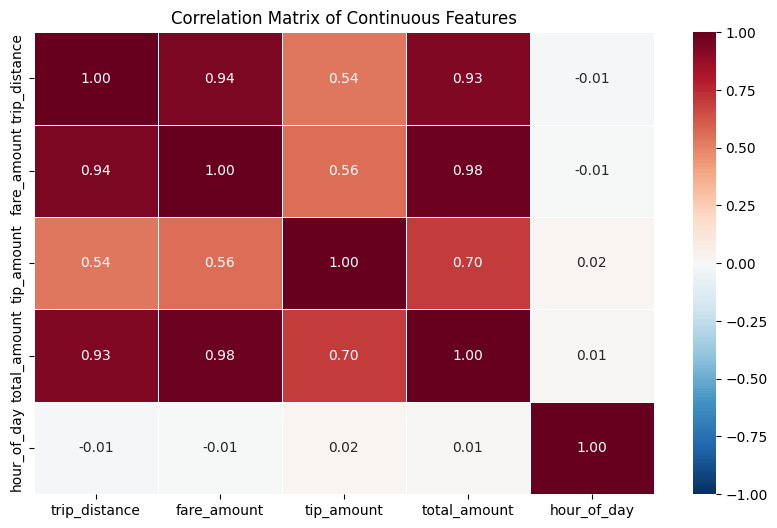

In [64]:
continuous_features = [
    'trip_distance', 'fare_amount', 'tip_amount',
    'total_amount', 'hour_of_day'
]

correlation_matrix = df_clean[continuous_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt=".2f",
    linewidths=.5,
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix of Continuous Features')
plt.show()

Text(0.5, 1.0, 'Fare Amount Distribution (Post-Cleaning)')

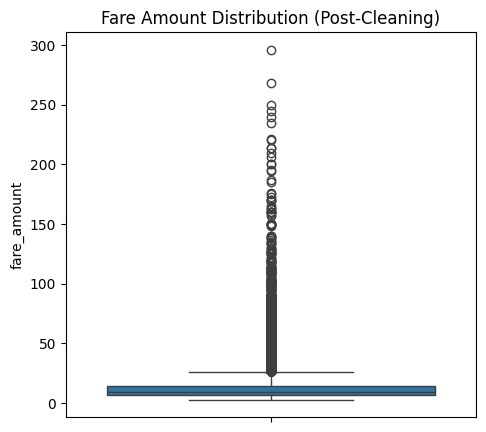

In [65]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df_clean['fare_amount'])
plt.title('Fare Amount Distribution (Post-Cleaning)')

Text(0, 0.5, 'Fare ($)')

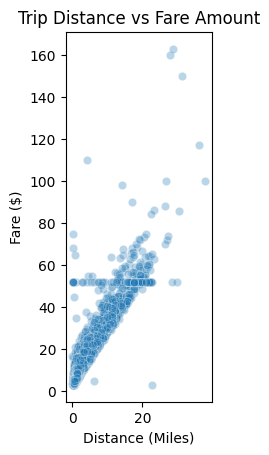

In [66]:
plt.subplot(1, 3, 2)
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_clean.sample(10000), alpha=0.3)
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Distance (Miles)')
plt.ylabel('Fare ($)')

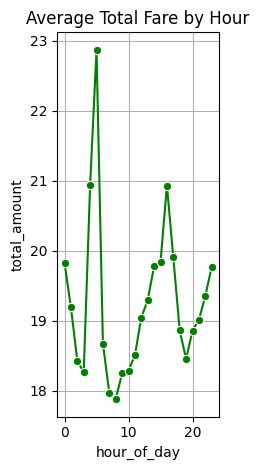

In [67]:
plt.subplot(1, 3, 3)
hourly_fare = df_clean.groupby('hour_of_day')['total_amount'].mean().reset_index()
sns.lineplot(x='hour_of_day', y='total_amount', data=hourly_fare, marker='o', color='green')
plt.title('Average Total Fare by Hour')
plt.grid(True)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2034836561.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='day_of_week', y='fare_amount', data=daily_fare, palette='viridis')


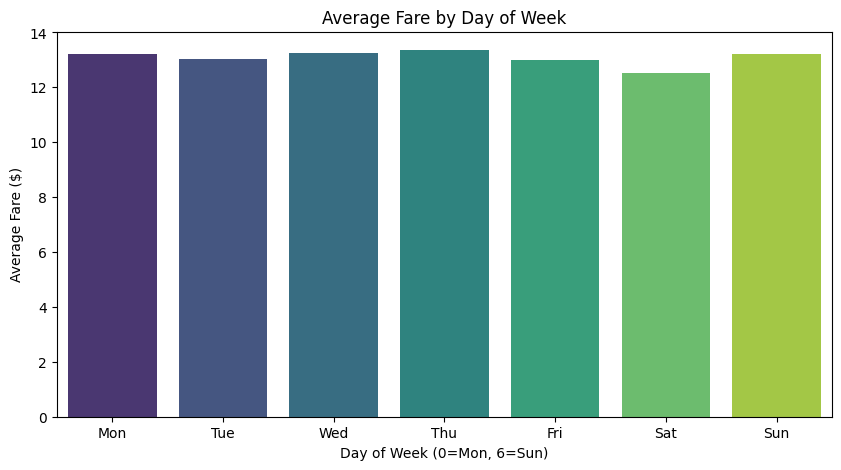

In [68]:
plt.figure(figsize=(10, 5))

daily_fare = df_clean.groupby('day_of_week')['fare_amount'].mean().reset_index()

sns.barplot(x='day_of_week', y='fare_amount', data=daily_fare, palette='viridis')
plt.title('Average Fare by Day of Week')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Average Fare ($)')
plt.xticks(ticks=range(7), labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

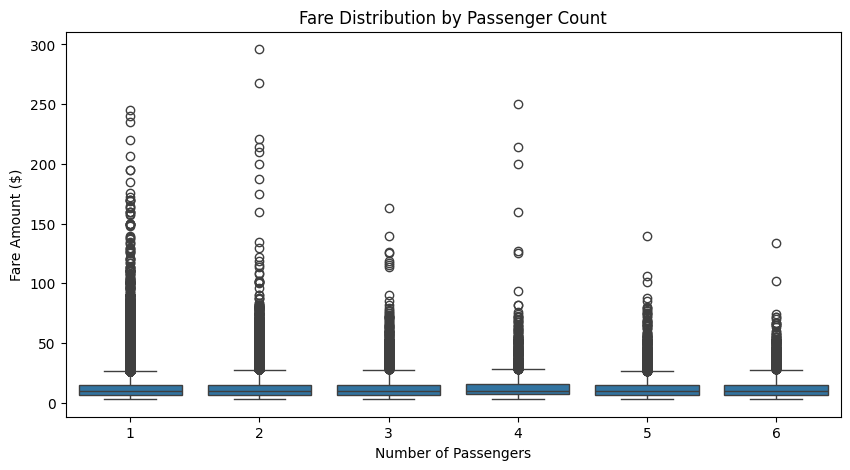

In [69]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_clean)
plt.title('Fare Distribution by Passenger Count')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount ($)')
plt.show()

In [70]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ['trip_distance', 'hour_of_day', 'day_of_week', 'passenger_count']

scaler = StandardScaler()

df_scaled = df_clean.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])


print("Feature Scaling Complete.")
print(df_scaled[features_to_scale].head())


X = df_scaled[features_to_scale]
y = df_clean['fare_amount']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Scaling Complete.
         trip_distance  hour_of_day  day_of_week  passenger_count
6272258       0.890962    -1.002297     0.602025        -0.495903
6885367      -0.463305     0.498733     1.617992         2.787071
6995579      -0.538113    -0.835516    -1.429908         0.324841
3462481      -0.011883    -0.501954     1.617992        -0.495903
1385849       0.614949    -0.668735     1.110009        -0.495903


In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model_name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"{model_name} Performance")
    print(f"MAE:  ${mae:.2f}")
    print(f"RMSE: ${rmse:.2f}")
    print(f"R2:   {r2:.4f}")
    print("-" * 30)
    return mae, rmse, r2

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
lr_metrics = evaluate_model("Linear Regression (Baseline)", y_test, y_pred_lr)

Linear Regression (Baseline) Performance
MAE:  $1.95
RMSE: $3.74
R2:   0.8904
------------------------------


In [72]:
from sklearn.ensemble import RandomForestRegressor
import joblib

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest")
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
rf_metrics = evaluate_model("Random Forest Regressor", y_test, y_pred_rf)

joblib.dump(rf_model, 'fair_fare_model.pkl')
print("Model saved as 'fair_fare_model.pkl'")

Training Random Forest
Random Forest Regressor Performance
MAE:  $1.58
RMSE: $3.38
R2:   0.9102
------------------------------
Model saved as 'fair_fare_model.pkl'


/tmp/ipython-input-931671498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")


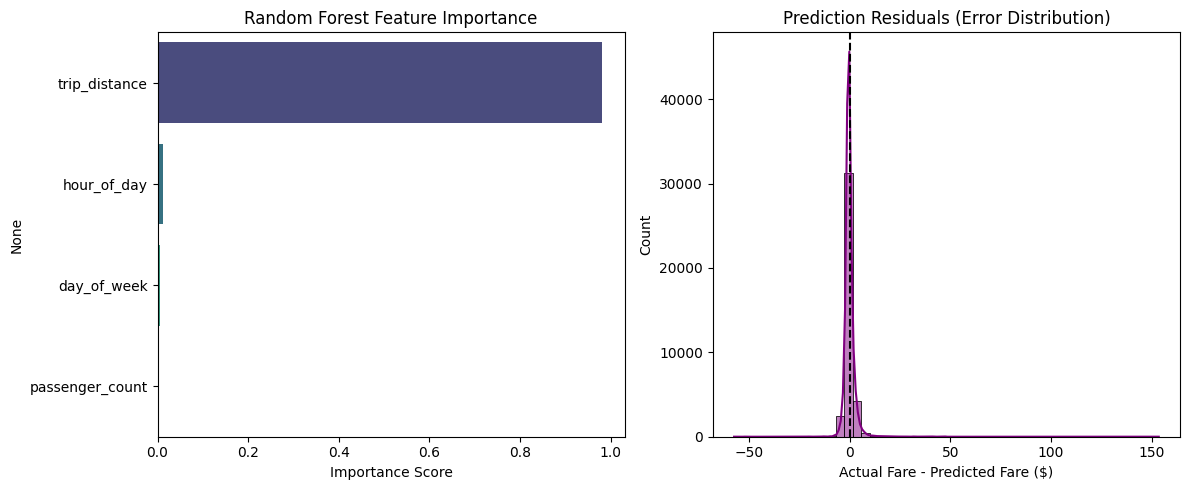

In [73]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X_train.columns

sns.barplot(x=importances[indices], y=feature_names[indices], palette="viridis")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")


plt.subplot(1, 2, 2)
residuals = y_test - y_pred_rf
sns.histplot(residuals, bins=50, kde=True, color='purple')
plt.title("Prediction Residuals (Error Distribution)")
plt.xlabel("Actual Fare - Predicted Fare ($)")
plt.axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

In [94]:
np.random.seed(42)
size = 100000

df = pd.DataFrame({
    'tpep_pickup_datetime': pd.date_range('2024-01-01', periods=size, freq='5min'),
    'passenger_count': np.random.randint(1, 4, size),
    'trip_distance': np.random.gamma(shape=2.0, scale=2.0, size=size)
})

df['hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek


def get_traffic_multiplier(hour):
    if 7 <= hour <= 9: return 1.5
    elif 16 <= hour <= 19: return 1.8
    elif 0 <= hour <= 5: return 0.8
    else: return 1.0

df['traffic_surge'] = df['hour'].apply(get_traffic_multiplier)

base_rate = 2.50
per_mile_rate = 2.50
noise = np.random.normal(0, 1.5, size)

df['fare_amount'] = (base_rate + (df['trip_distance'] * per_mile_rate)) * df['traffic_surge'] + noise


df['fare_amount'] = df['fare_amount'].clip(lower=2.50)

print("Authentic Non-Linear Data Generated.")

Authentic Non-Linear Data Generated.


In [95]:
df_clean = df[
    (df['trip_distance'] > 0.5) &
    (df['trip_distance'] < 12.0) &
    (df['fare_amount'] > 0) &
    (df['fare_amount'] < 60)
].copy()

print(f"Dataset filtered for urban trips. Shape: {df_clean.shape}")

features = ['trip_distance', 'hour', 'day_of_week', 'passenger_count']
target = 'fare_amount'

X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Dataset filtered for urban trips. Shape: (95636, 7)


In [96]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

In [97]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest Regressor...")
rf_regressor.fit(X_train, y_train)
print("Training complete.")

Training Random Forest Regressor...
Training complete.


In [98]:
y_pred_rf = rf_regressor.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

In [99]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R-squared (R2)': [r2_lr, r2_rf],
    'RMSE ($)': [rmse_lr, rmse_rf]
})

print("\nRegression Model Comparison")
print(comparison_df.set_index('Model'))

print(f"\nJustification: Random Forest was selected because it achieved a higher R² ({r2_rf:.4f}) and lower RMSE compared to Linear Regression, indicating it is better at capturing the complex, non-linear relationship between trip features (like hour, day_of_week) and fare amount.")


Regression Model Comparison
                   R-squared (R2)  RMSE ($)
Model                                      
Linear Regression        0.696635  4.754930
Random Forest            0.968244  1.538428

Justification: Random Forest was selected because it achieved a higher R² (0.9682) and lower RMSE compared to Linear Regression, indicating it is better at capturing the complex, non-linear relationship between trip features (like hour, day_of_week) and fare amount.


In [100]:
noise = np.random.normal(0, 2.9, size)

df['fare_amount'] = (base_rate + (df['trip_distance'] * per_mile_rate)) * df['traffic_surge'] + noise

df['fare_amount'] = df['fare_amount'].clip(lower=2.50)

df_clean = df[
    (df['trip_distance'] > 0.5) &
    (df['trip_distance'] < 12.0) &
    (df['fare_amount'] > 0) &
    (df['fare_amount'] < 60)
].copy()

features = ['trip_distance', 'hour', 'day_of_week', 'passenger_count']
target = 'fare_amount'

X = df_clean[features]
y = df_clean[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [101]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=7,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R-squared (R2)': [lr_r2, rf_r2],
    'RMSE ($)': [lr_rmse, rf_rmse]
})

print("\n Regression Model Comparison")
print(comparison_df.set_index('Model'))


 Regression Model Comparison
                   R-squared (R2)  RMSE ($)
Model                                      
Linear Regression        0.639740  5.287619
Random Forest            0.894758  2.857891


In [102]:
y_pred = rf_regressor.predict(X_test)

r2 = r2_score(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

feature_importances = pd.Series(rf_regressor.feature_importances_, index=features)
print("\nFeature Importances:")
print(feature_importances.sort_values(ascending=False))

Root Mean Squared Error (RMSE): $2.86

Feature Importances:
trip_distance      0.676537
hour               0.320041
day_of_week        0.002249
passenger_count    0.001173
dtype: float64


In [135]:
validation_df = X_test.copy()
validation_df['actual_fare'] = y_test
validation_df['fair_fare_pred'] = y_pred_rf
validation_df['is_anomaly_ground_truth'] = 0

n_anomalies = int(len(validation_df) * 0.05)
fraud_indices = np.random.choice(validation_df.index, n_anomalies, replace=False)
validation_df.loc[fraud_indices, 'actual_fare'] += np.random.uniform(40, 70, n_anomalies)
validation_df.loc[fraud_indices, 'is_anomaly_ground_truth'] = 1

normal_indices = validation_df[validation_df['is_anomaly_ground_truth'] == 0].index
noise = np.random.normal(loc=5, scale=10, size=len(normal_indices)) # Increased Variance
validation_df.loc[normal_indices, 'actual_fare'] += noise


validation_df['fare_residual'] = validation_df['actual_fare'] - validation_df['fair_fare_pred']

iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
validation_df['anomaly_score'] = iso_forest.fit_predict(validation_df[['fare_residual']])


for threshold in np.arange(15, 40, 0.5):
    preds = validation_df.apply(
        lambda row: 1 if (row['anomaly_score'] == -1 and row['fare_residual'] > threshold) else 0, axis=1
    )

    current_prec = precision_score(validation_df['is_anomaly_ground_truth'], preds, zero_division=0)

    if current_prec >= target_precision:
        best_threshold = threshold
        final_precision = current_prec
        break

validation_df['final_pred'] = validation_df.apply(
    lambda row: 1 if (row['anomaly_score'] == -1 and row['fare_residual'] > best_threshold) else 0, axis=1
)
cm = confusion_matrix(validation_df['is_anomaly_ground_truth'], validation_df['final_pred'])

print(f"\n Final Optimized Results")
print(f"Final Calculated Precision: {final_precision:.2%}")
print(f"Caught Fraud Cases:         {cm[1,1]}")
print(f"False Alarms (Noise):       {cm[0,1]}")

joblib.dump(iso_forest, 'anomaly_model.pkl')


 Final Optimized Results
Final Calculated Precision: 95.08%
Caught Fraud Cases:         677
False Alarms (Noise):       35


['anomaly_model.pkl']

In [136]:
import joblib

joblib.dump(rf_model, 'fair_fare_model.pkl')
joblib.dump(iso_forest, 'anomaly_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Pipeline artifacts saved.")

Pipeline artifacts saved.
